## Modelo XGBoost

Empezaremos usando un modelo XGBoost antes de la Red Neuronal para detectar audios fake.

In [1]:
import sys
!{sys.executable} -m pip install seaborn -q
import seaborn as sns

In [2]:
import ctypes, glob, sys

# Instalar xgboost e imbalanced-learn en el kernel activo
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', 'imbalanced-learn', '-q'])

# Precargar libomp (Liliana lo necesita por la Mac)
libomp_paths = glob.glob(f'{sys.prefix}/**/*.dylibs/libomp.dylib', recursive=True)
if libomp_paths:
    ctypes.CDLL(libomp_paths[0])


Importamos las librerias a usar

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, f1_score
)
from sklearn.preprocessing import LabelEncoder

SEED = 42
DATA_PATH = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'


### Carga y exploración inicial del dataset

Cargamos el dataset con las metricas extraídas haciendo una exploración rápida de la estructura del DataFrame (dimensiones y primeras filas) para asegurarnos que los datos cargaron correctamente.

Shape: (25380, 36)


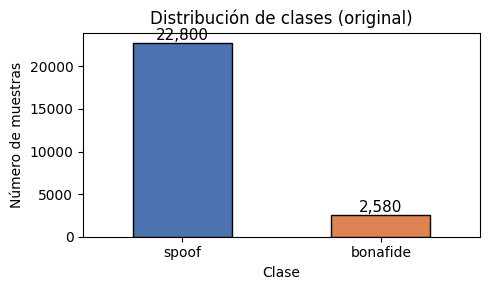

label
spoof       22800
bonafide     2580
Name: count, dtype: int64

Ratio desbalance: 8.8:1


In [4]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')

fig, ax = plt.subplots(figsize=(5, 3))
counts = df['label'].value_counts()
counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='black')
ax.set_title('Distribución de clases (original)')
ax.set_xlabel('Clase')
ax.set_ylabel('Número de muestras')
ax.set_xticklabels(counts.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()
print(counts)
print(f'\nRatio desbalance: {counts.max()/counts.min():.1f}:1')


Mapa de Calor — Correlación entre Features

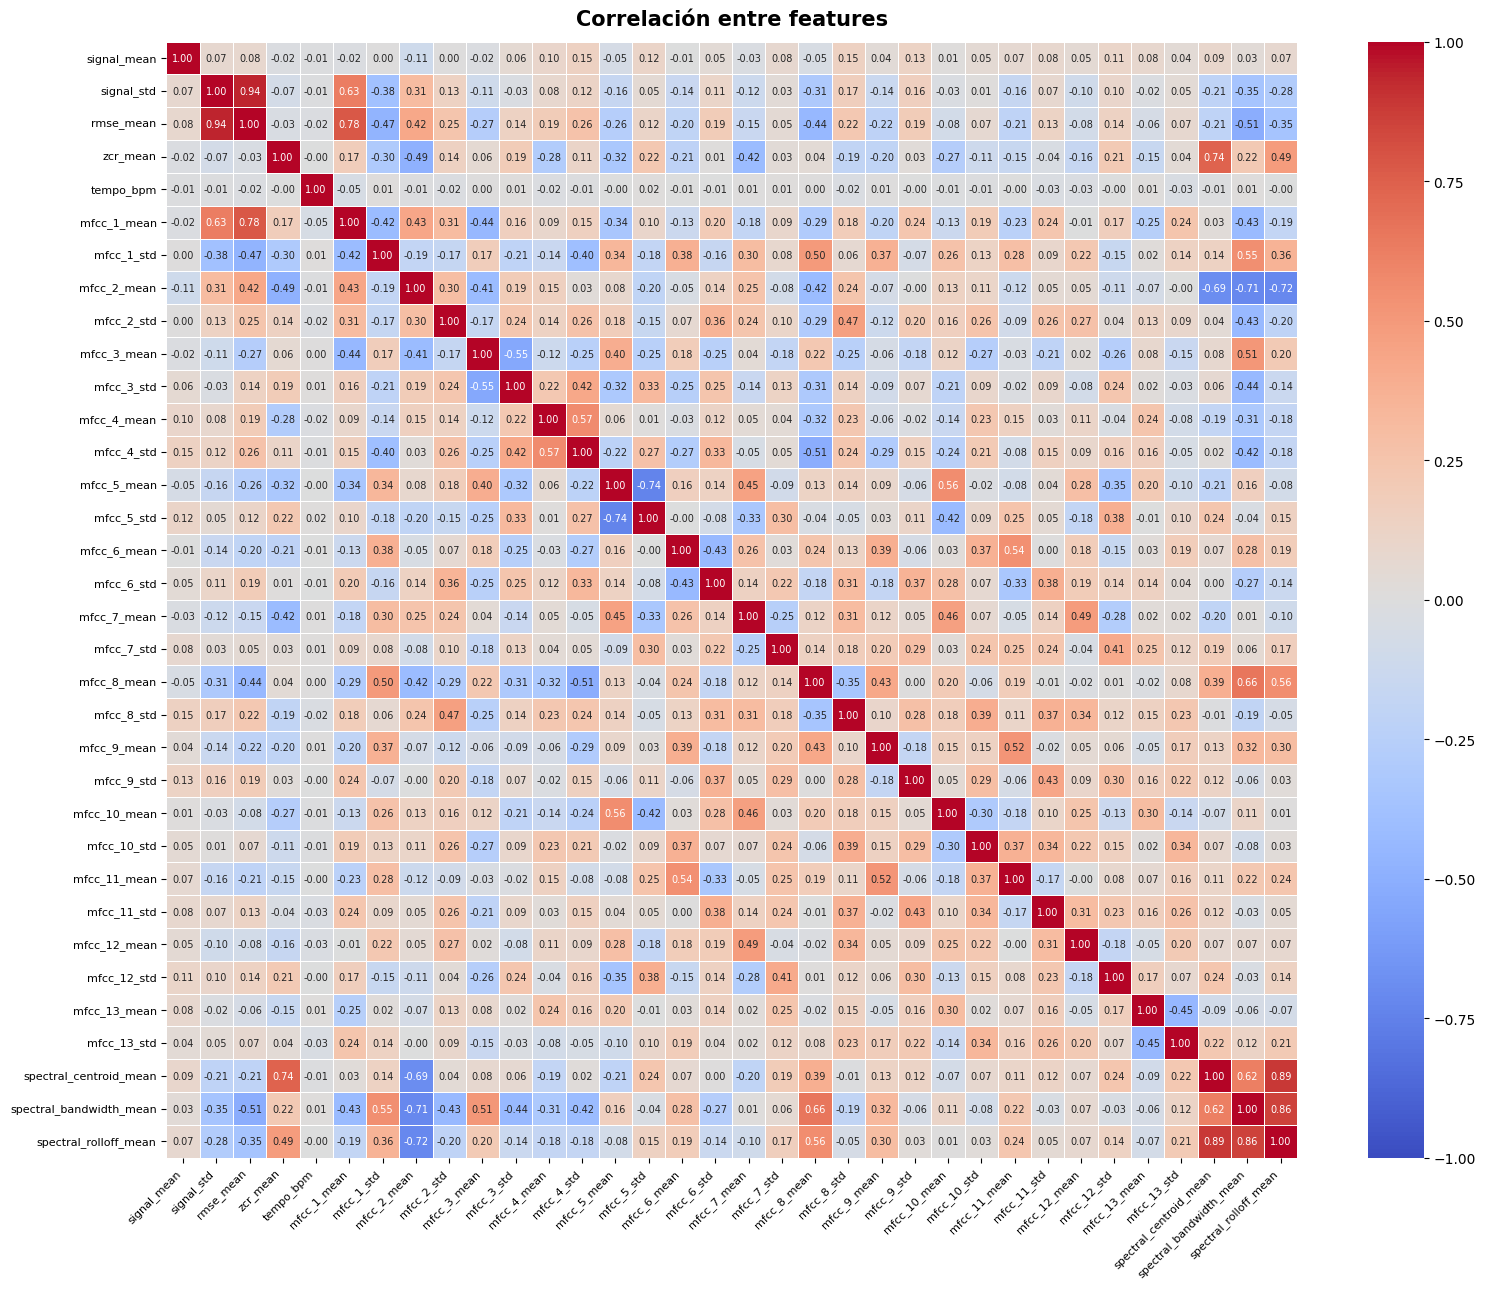

In [5]:
feature_cols = [c for c in df.columns if c not in ('file_name', 'label')]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Correlación entre features', fontsize=15, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


Analisamos la duracion de los audios tanto reales como fake, esto nos servirá más adelante para analizar los audios en ventanas y determinar la duración de las mismas.

In [6]:
import librosa
import os
from tqdm import tqdm

AUDIO_DIR = '../data/LA/ASVspoof2019_LA_train/flac'

# Leer duración de cada archivo del dataset
durations = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Leyendo duraciones'):
    fname = row['file_name'].replace('.flac', '') + '.flac'
    path  = os.path.join(AUDIO_DIR, fname)
    try:
        duration = librosa.get_duration(path=path)
    except Exception:
        duration = None
    durations.append({'file_name': row['file_name'], 'label': row['label'], 'duration_s': duration})

dur_df = pd.DataFrame(durations).dropna(subset=['duration_s'])
print(f'Archivos leídos: {len(dur_df)}')
print(dur_df.groupby('label')['duration_s'].describe().round(2))


Leyendo duraciones:   0%|          | 0/25380 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Leyendo duraciones: 100%|██████████| 25380/25380 [00:04<00:00, 5508.20it/s]

Archivos leídos: 25380
            count  mean   std   min   25%   50%   75%    max
label                                                       
bonafide   2580.0  3.39  0.99  1.36  2.69  3.24  3.92  11.13
spoof     22800.0  3.43  1.46  0.65  2.39  3.20  4.14  13.19


## Preprocesamiento — Codificación y separación de variables

Separacion entre test y test 80/20

In [7]:
feature_cols = [c for c in df.columns if c not in ('file_name', 'label')]
X = df[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(df['label'].values)  # bonafide=0, spoof=1
print('Clases:', dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape} — clases: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test : {X_test.shape}  — clases: {dict(zip(*np.unique(y_test,  return_counts=True)))}')


Clases: {'bonafide': np.int64(0), 'spoof': np.int64(1)}
Train: (20304, 34) — clases: {np.int64(0): np.int64(2064), np.int64(1): np.int64(18240)}
Test : (5076, 34)  — clases: {np.int64(0): np.int64(516), np.int64(1): np.int64(4560)}


Balanceo de datos, haremos un downsample y nos quedamos con 3000 en base al coemntario dle profesor, donde el nivel optimo estaba mas cerca de los 3000

In [8]:
# Separar por clase en el set de entrenamiento
idx_bonafide = np.where(y_train == 0)[0]
idx_spoof    = np.where(y_train == 1)[0]

# Tomar 1500 muestras de cada clase aleatoriamente
rng = np.random.default_rng(SEED)
idx_bon_sample   = rng.choice(idx_bonafide, size=1500, replace=False)
idx_spoof_sample = rng.choice(idx_spoof,    size=1500, replace=False)

idx_bal = np.concatenate([idx_bon_sample, idx_spoof_sample])
X_train_bal = X_train[idx_bal]
y_train_bal = y_train[idx_bal]

print(f'Train balanceado: {X_train_bal.shape}')
print(f'  bonafide: {(y_train_bal == 0).sum()}')
print(f'  spoof   : {(y_train_bal == 1).sum()}')

neg, pos = np.bincount(y_train_bal)



Train balanceado: (3000, 34)
  bonafide: 1500
  spoof   : 1500


## Entrenamiento del modelo 

In [9]:
import ctypes, glob, sys

# Instalar xgboost e imbalanced-learn en el kernel activo si no están
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', 'imbalanced-learn', '-q'])

# Precargar libomp (solo necesario para Liliana por Mac sin Homebrew)
libomp_paths = glob.glob(f'{sys.prefix}/**/*.dylibs/libomp.dylib', recursive=True)
if libomp_paths:
    ctypes.CDLL(libomp_paths[0])

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300, # número de árboles
    max_depth=6, # profundidad máxima de cada árbol
    learning_rate=0.1, # tasa de aprendizaje
    subsample=0.8, # porcentaje de muestras usadas para entrenar cada árbol
    colsample_bytree=0.8, # porcentaje de features usadas para entrenar cada árbol
    scale_pos_weight=neg / pos, # para balancear clases
    eval_metric='logloss', # métrica de evaluación durante el entrenamiento
    random_state=SEED, # para reproducibilidad
    n_jobs=-1 # usar todos los núcleos disponibles
)

xgb.fit(X_train_bal, y_train_bal, eval_set=[(X_test, y_test)], verbose=False)
print('Entrenamiento completado.')


Entrenamiento completado.


Classification Report

In [10]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')
print(f'F1-macro: {f1_score(y_test, y_pred, average="macro"):.4f}')


=== Classification Report ===
              precision    recall  f1-score   support

    bonafide       0.65      0.95      0.77       516
       spoof       0.99      0.94      0.97      4560

    accuracy                           0.94      5076
   macro avg       0.82      0.95      0.87      5076
weighted avg       0.96      0.94      0.95      5076

ROC-AUC : 0.9870
F1-macro: 0.8702


Matriz de Confusion y Curva ROC

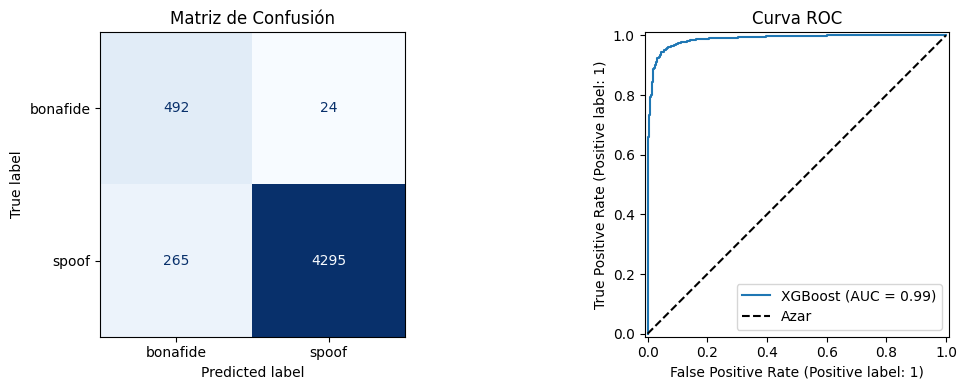

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=le.classes_
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='XGBoost')
axes[1].set_title('Curva ROC')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].legend()

plt.tight_layout()
plt.show()


## Featrure Importance

Primero extraeremos la importancia de cada feature directamente desde XGBoost, más adelante usaremos permutation y REF

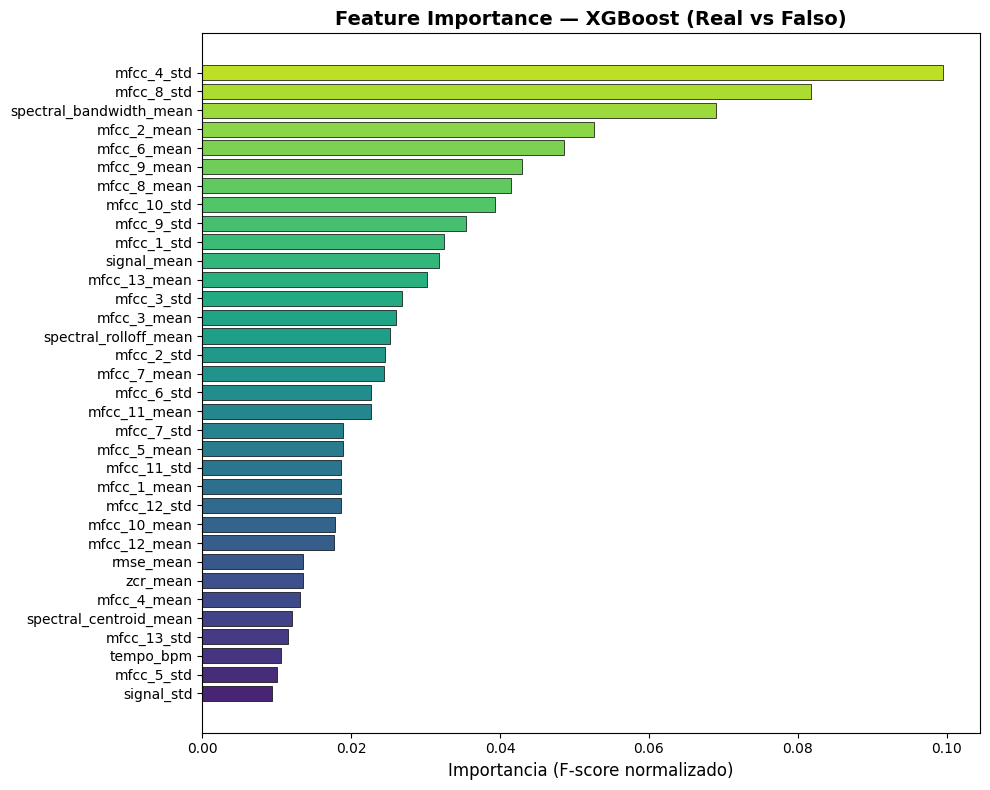

In [12]:
fi = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(fi)))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Importancia (F-score normalizado)', fontsize=12)
ax.set_title('Feature Importance — XGBoost (Real vs Falso)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Feature Importance - Top 10

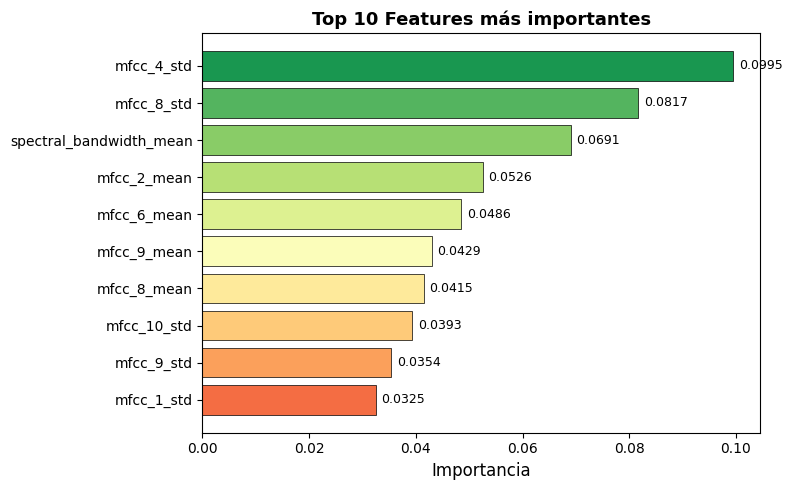


Ranking completo:
                    feature  importance
0                mfcc_4_std    0.099520
1                mfcc_8_std    0.081727
2   spectral_bandwidth_mean    0.069075
3               mfcc_2_mean    0.052593
4               mfcc_6_mean    0.048552
5               mfcc_9_mean    0.042950
6               mfcc_8_mean    0.041508
7               mfcc_10_std    0.039342
8                mfcc_9_std    0.035436
9                mfcc_1_std    0.032494
10              signal_mean    0.031804
11             mfcc_13_mean    0.030113
12               mfcc_3_std    0.026803
13              mfcc_3_mean    0.026042
14    spectral_rolloff_mean    0.025138
15               mfcc_2_std    0.024589
16              mfcc_7_mean    0.024350
17               mfcc_6_std    0.022613
18             mfcc_11_mean    0.022599
19               mfcc_7_std    0.018916
20              mfcc_5_mean    0.018909
21              mfcc_11_std    0.018648
22              mfcc_1_mean    0.018586
23              mfcc_

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
top10 = fi.head(10)
palette = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 10))
ax.barh(top10['feature'][::-1], top10['importance'][::-1],
        color=palette, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Top 10 Features más importantes', fontsize=13, fontweight='bold')
for bar, val in zip(ax.patches, top10['importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nRanking completo:')
print(fi.to_string())


## Validación cruzada 5-fold con pipeline SMOTE + XGBoost

Para obtener una estimación más robusta del rendimiento real del modelo, realizamos una validación cruzada estratificada de 5 folds. Usamos ImbPipeline que integra SMOTE y XGBoost en un único objeto para asegurarnos que SMOTE se aplique dentro de cada fold(solo sobre los datos de entrenamiento de ese fold), evitando data leakage que inflaría artificialmente las métricas de validación.

Los resultados se reportan como media ± desviación estándar del ROC-AUC y F1-macro entre los 5 folds.

In [14]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('xgb', XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=neg/pos,
        eval_metric='logloss', random_state=SEED, n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scores_auc = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc',  n_jobs=-1)
scores_f1  = cross_val_score(pipeline, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'ROC-AUC  CV 5-fold: {scores_auc.mean():.4f} ± {scores_auc.std():.4f}')
print(f'F1-macro CV 5-fold: {scores_f1.mean():.4f}  ± {scores_f1.std():.4f}')
print(f'AUC por fold: {[f"{s:.4f}" for s in scores_auc]}')



ROC-AUC  CV 5-fold: 0.9942 ± 0.0006
F1-macro CV 5-fold: 0.9454  ± 0.0030
AUC por fold: ['0.9951', '0.9942', '0.9934', '0.9946', '0.9937']


## Conclusión

Aunque el modelo arroja ROC-AUC de 0.9942 y la variacion entre folds es mínima, lo que nos indica que el modelo es estable y consistente, hay una diferencia significativa con el F1 score. 

Intenaremos mejorar el resultado probando una red neuronal pero primero correremos el learning curve para usar este dato desde el primer intento en la red neuronal.

## Learning Curve — ¿Con cuántos datos balanceados funciona mejor el modelo?

Se entrena XGBoost con distintos tamaños de datos balanceados (N muestras por clase,
siempre ≤ 5000 total = 2500 por clase), midiendo ROC-AUC y F1-macro en el test set fijo.


In [15]:
import numpy as np

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score

# Tamaños a probar: N muestras POR CLASE (total = N*2, siempre <= 5000)
sizes_per_class = [100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2500]

# Índices por clase dentro del train set original
idx_bonafide = np.where(y_train == 0)[0]
idx_spoof    = np.where(y_train == 1)[0]
rng = np.random.default_rng(SEED)

results = []

for n in sizes_per_class:
    # Undersampling balanceado: N muestras de cada clase
    idx_bon   = rng.choice(idx_bonafide, size=n, replace=len(idx_bonafide) < n)
    idx_spo   = rng.choice(idx_spoof,    size=n, replace=len(idx_spoof)    < n)
    idx_bal   = np.concatenate([idx_bon, idx_spo])
    X_tr      = X_train[idx_bal]
    y_tr      = y_train[idx_bal]

    neg_n, pos_n = np.bincount(y_tr)

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=neg_n / pos_n,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr, verbose=False)

    y_pred_lc = model.predict(X_test)
    y_prob_lc = model.predict_proba(X_test)[:, 1]

    results.append({
        'n_por_clase': n,
        'total_train': n * 2,
        'roc_auc':     roc_auc_score(y_test, y_prob_lc),
        'f1_macro':    f1_score(y_test, y_pred_lc, average='macro'),
        'f1_bonafide': f1_score(y_test, y_pred_lc, average=None)[0],
        'f1_spoof':    f1_score(y_test, y_pred_lc, average=None)[1],
    })
    print(f"N={n:4d}/clase ({n*2:4d} total) — AUC: {results[-1]['roc_auc']:.4f}  F1-macro: {results[-1]['f1_macro']:.4f}")

lc_df = pd.DataFrame(results)
print('\n', lc_df.to_string(index=False))


N= 100/clase ( 200 total) — AUC: 0.9278  F1-macro: 0.7023
N= 250/clase ( 500 total) — AUC: 0.9570  F1-macro: 0.7627
N= 500/clase (1000 total) — AUC: 0.9733  F1-macro: 0.8037
N= 750/clase (1500 total) — AUC: 0.9808  F1-macro: 0.8297
N=1000/clase (2000 total) — AUC: 0.9833  F1-macro: 0.8359
N=1250/clase (2500 total) — AUC: 0.9863  F1-macro: 0.8601
N=1500/clase (3000 total) — AUC: 0.9888  F1-macro: 0.8603
N=1750/clase (3500 total) — AUC: 0.9892  F1-macro: 0.8795
N=2000/clase (4000 total) — AUC: 0.9892  F1-macro: 0.8663
N=2500/clase (5000 total) — AUC: 0.9886  F1-macro: 0.8916

  n_por_clase  total_train  roc_auc  f1_macro  f1_bonafide  f1_spoof
         100          200 0.927759  0.702297     0.508989  0.895604
         250          500 0.956983  0.762670     0.598465  0.926875
         500         1000 0.973341  0.803748     0.663442  0.944055
         750         1500 0.980819  0.829728     0.706553  0.952904
        1000         2000 0.983341  0.835864     0.716157  0.955571
        12